## Question 1

**a. Load the telecom-monthly.csv dataset into Python as a pandas DataFrame.**


In [80]:
import pandas as pd
#Reading the dataset: telecom-monthly.csv
m_df = pd.read_csv("telecom-monthly.csv")


**b. Inspect the data. How many customers are included in this dataset? How many
different variables are included? Does this dataset contain any missing values?**


In [82]:
#Number of unique customer ids
print("The number of different customers is:", m_df["customer_id"].nunique(), "\n")

#.shape[1] is the number of columns - variables
print("The number of different variable included is: ", m_df.shape[1])

#Printing if the dataset has any null values.
#If it contains any, we are printing the number of missing values per column.
#If not, we just print a message that the dataset does not contain any missing values.
if (sum(m_df.isna().sum()) == 0):
    print("\nThat means that the dataset contains no missing values!")
else:
    print("For each column, the number of missing values is:\n\n", m_df.isna().sum(), sep='')




The number of different customers is: 800 

The number of different variable included is:  11

That means that the dataset contains no missing values!



We have **800 different customes**, **11 different variables** and no **missing values**



**c. Perform an exploratory data analysis, creating both numerical and graphical
summaries of the data. Pay particular attention to the distribution of the churn
variable and the relationship between tenure and monthly charges. Discuss and
interpret your results.**


In [83]:
print(m_df.describe())
print("\nTotal income per month = ", sum(m_df["monthly_charges"]), "\nTotal income: ", sum(m_df["total_charges"]))

       customer_id      tenure  monthly_charges  total_charges  \
count     800.0000  800.000000       800.000000     800.000000   
mean     1399.5000   18.875000        65.000362    1256.837075   
std       231.0844   17.411874        16.861907    1280.216807   
min      1000.0000    1.000000        20.640000      22.940000   
25%      1199.7500    6.000000        53.905000     346.280000   
50%      1399.5000   13.000000        64.980000     827.985000   
75%      1599.2500   26.000000        76.842500    1710.880000   
max      1799.0000   72.000000       107.850000    7407.360000   

       streaming_services      churn  
count          800.000000  800.00000  
mean             1.001250    0.43625  
std              0.782313    0.49623  
min              0.000000    0.00000  
25%              0.000000    0.00000  
50%              1.000000    0.00000  
75%              2.000000    1.00000  
max              2.000000    1.00000  

Total income per month =  52000.29 
Total income:  10


- Looking at the mean of `churn`, we understand that around **44%** of the customers have canceled their subscription.

- The average subscriber is a customer for around 18.9 months, with a standard deviation of 17.4, so the regular period span is from 1.5 months to 36.3 months, which is a wide space and proves that the variation of tenure is large.

- A customer spends around 65 euros every month for subscription, with a standard deviation around 17 euros, and total `monthly_charges` are over 52,000 euros.

- `Total charges` (total income) is close to 1,005,469 euros, and the mean per customer is close to 1,256.84 euros, with a standard deviation at approximately 1,280 euros and a 75% quantile at 1,711 euros.

- From the 3 quantiles, mean, and standard deviation, the most common streaming service appears to be option 1, followed by option 2, and then option 0.



In [84]:
import seaborn as sns
sns.set_style("darkgrid")


The correlation between tenure and monthly_charges is:                     tenure  monthly_charges
tenure           1.000000         0.102156
monthly_charges  0.102156         1.000000


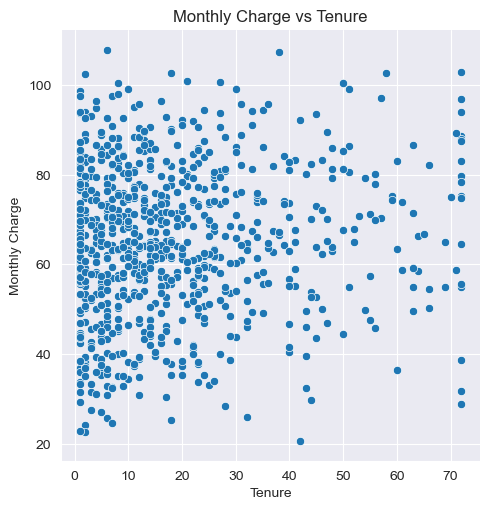

In [166]:
sns.relplot(data=m_df, x="tenure", y="monthly_charges");
plt.title("Monthly Charge vs Tenure")
plt.ylabel("Monthly Charge")
plt.xlabel("Tenure")

print("\nThe correlation between tenure and monthly_charges is: ", m_df[["tenure", "monthly_charges"]].corr())


We notice that the correlation between `tenure` and `monthly_charges` is very low, which can also be seen in the plot. However, we notice a huge gathering of data when tenure is close to 1 and monthly charges are approximately from 60 euros to a little less than 80 euros. That gathering continues at the same range of `monthly_charges` as `tenure` progresses, until we reach tenure equal to 70 months. From that point on, the monthly charges vary, but are gathering from around 68 euros monthly charge and more. That indicates that customers who stayed long do not necessarily have more expensive subscriptions, since the monthly charges remain spread out.


In [86]:
## Question 2


**a. Load the telecom-yearly.csv dataset into Python as a pandas DataFrame.**


In [170]:
#Reading the dataset: telecom-monthly.csv
y_df = pd.read_csv("telecom-yearly.csv")


**b. Inspect the data. How many customers are included in this dataset? Are the
variables the same as those in the monthly contract group?**


In [88]:
# The number of customers in telecom-yearly dataset
print("The number of different customers is:", y_df["customer_id"].nunique(), "\n")


# Checking if the variables are the same
if list(y_df.columns) == list(m_df.columns):
    print("The variables are the same in both datasets!")
else:
    print("The variables aren't the same in both datasets.")
    print("The yearly variables are:", y_df.columns.tolist())
    print("The monthly variables are:", m_df.columns.tolist())



The number of different customers is: 600 

The variables are the same in both datasets!



We have the **600 customers** and the **same varaibles**.



**c. Perform a t-test, for each of the numerical measurements (tenure,
monthly_charges, total_charges), to test whether any of these indicators differ
between the monthly and yearly contract groups. Use a significance level of
Display the t-score and p-value for each measurement. Clearly state the
conclusion of your tests and explain your reasoning.**


In [89]:
#importing cpipy.stats in order to use advanced
#stats functions like t-test and chi-square.
import scipy.stats as stats

a = 0.05

#t-test for tenure
t_test, p_value = stats.ttest_ind(m_df["tenure"], y_df["tenure"])
print("For tenure: \n t-test = ", t_test, "\n p-value = ", p_value)

#checking if "tenure" is significant
if (p_value < a):
    print(" tenure, is a significant variable\n")
else:
    print(" tenure, is not a significant variable\n")

#t-test for monthly charges
t_test, p_value = stats.ttest_ind(m_df["monthly_charges"], y_df["monthly_charges"])
print("For monthly_charges: \n t-test = ", t_test, "\n p-value = ", p_value)

#checking if "monthly_charges" is significant
if (p_value < a):
    print(" monthly_charges, is a significant variable\n")
else:
    print(" monthly_charges, is not a significant variable\n")

    
#t-test for total charges.
t_test, p_value = stats.ttest_ind(m_df["total_charges"], y_df["total_charges"])
print("For total_charges: \n t-test = ", t_test, "\n p-value = ", p_value)


#checking if "total_charges" is significant
if (p_value < a):
    print(" total_charges, is a significant variable")
else:
    print(" total_charges, is not a  variable")

    

For tenure: 
 t-test =  -11.272065184410724 
 p-value =  2.867195647580132e-28
 tenure, is a significant variable

For monthly_charges: 
 t-test =  -1.313821578790745 
 p-value =  0.18912180536982376
 monthly_charges, is not a significant variable

For total_charges: 
 t-test =  -10.31489128213649 
 p-value =  4.300297534481614e-24
 total_charges, is a significant variable


**For tenure:**

 - The t-test is around –11.27. That is a considerable difference and it means that the yearly customers have a higher average tenure. So yearly customers tend to stick around for a longer time period than the monthly customers.

 - The p-value has reached \(2.87 \times 10^{-28}\). That is a very low number and proves that tenure is significant. This strongly indicates that the difference between the tenure of our two datasets is not random. So a pattern exists between the two tenures.

- 

**For monthly_charges:**

 - The t-test is approximately –1.31. There is a small difference between the two monthly_charges. To be more precise, the yearly customers are charged on average around 1.31 euros more.

 - The p-value this time is large, close to 0.19. That means that the monthly_charges between the two datasets do not show any significant difference and that monthly_charges is insignificant.


**For total_charges**

 - The t-test this time is –10.31, which shows a very large difference between the average total charges of the two groups. The negative sign indicates that yearly customers have a higher average total charge compared to monthly customers.

 - The p-value is close to \(4.30 \times 10^{-24}\). That is a very small number that clearly indicates that total_charges is significant. In fact, it is so small that it suggests the difference between the two groups is not random, and that a real pattern exists between the total_charges of our dataset.


**d. Create a chi-square test to determine if churn rates differ significantly between the
two contract types. Compare the two datasets using appropriate graphical means,
including a comparison of churn rates.**

Contingency table:
       Month  Year
churn             
0        451   461
1        349   139

chi-square = 62.299042143011235
p-value = 2.950685691455726e-15 



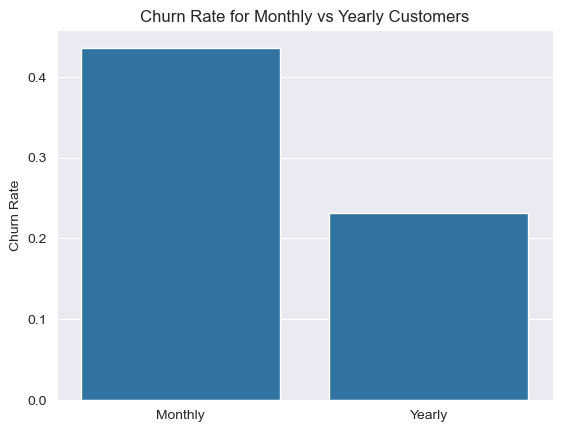

In [90]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

#we need to add even tables in orer to create the Contingency table 
churn = pd.DataFrame({
    "Month": m_df["churn"].value_counts(),
    "Year": y_df["churn"].value_counts()
}).fillna(0)

#creating the contingency table
chi2, p, dof, expected = chi2_contingency(churn)

print("Contingency table:")
print(churn)

print("\nchi-square =", chi2)
print("p-value =", p, "\n")

m_churn = m_df["churn"].mean()
y_churn = y_df["churn"].mean()

sns.barplot(x=["Monthly", "Yearly"], y=[m_churn, y_churn])
plt.ylabel("Churn Rate")
plt.title("Churn Rate for Monthly vs Yearly Customers")
plt.show()



The chi-square value is close to 62.3. That is a large number and shows that there is a strong difference in churn between the yearly and monthly datasets. The p-value is also extremely small and supports this result even more, since compared to the earlier alpha level it is clearly significant.



## Question 3

**a. Combine the two datasets into a single DataFrame, adding a column to identify the
original dataset.**


In [171]:
# Combining the datasets into a single DataFrame
#with  a new column that identifies
# the original dataset the data came from (monthly or yearly).
combined_df = pd.concat([
    m_df.assign(contract_group="monthly"),
    y_df.assign(contract_group="yearly")
], ignore_index=True)


**b. Compute the Pearson correlation coefficient between each of the numerical
measurements and identify which indicators are most correlated. List the three
most strongly correlated pairs.**


In [92]:
import numpy as np


corr_matrix = combined_df.corr(numeric_only=True)

#We take absolute correlations and get a correlation matrix.
corr_matrix = corr_matrix.abs()

# We need only the upper-triangle data, since the lower-triangle are duplicated in the correlation matrix.
#We will mask in order to avoid duplicate pairs.
#We will mark the lower triangle as True and use mask in order to
#remove that data, so there will be no repeated correlations and
#no "self correlations" that are equal to 1.
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=0)
corr_matrix = corr_matrix.mask(mask)

# We unstack, drop the null values and sort in  descending order.
corr_matrix = corr_matrix.unstack().dropna().sort_values(ascending=False)

# Let's print the 3 best correlation pairs and see if
#which ones have a strong correlation
print("\nThe three strongest correlated pairs are: \n")
print( corr_matrix.head(3))



The three strongest correlated pairs are: 

total_charges       tenure             0.937605
churn               tenure             0.400820
streaming_services  monthly_charges    0.387367
dtype: float64



**c. Create scatter plots for each of the correlated pairs identified in Q3(b). Add a
regression line to each plot. Are the relationships as expected from the correlation
coefficients?**


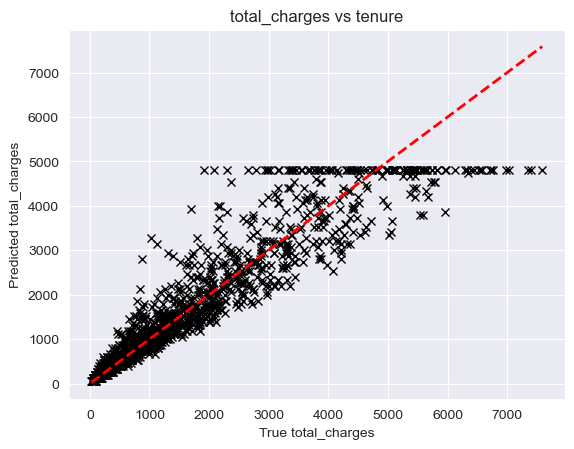

In [93]:
from sklearn import linear_model

#plotting for total_changes vs tenure

#we determine the variables we want to plot as x_train and y_train 
X_train = combined_df[["tenure"]]
y_train = combined_df["total_charges"]

#We fit the data into the model
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)
reg_test_pred = reg.predict(X_train)

#We create the plot
plt.plot(y_train, reg_test_pred, 'kx')
plt.plot([y_train.min(), y_train.max()], 
         [y_train.min(), y_train.max()], 
         ls="--", linewidth = 2,
        color="red")
plt.title("total_charges vs tenure")
plt.xlabel("True total_charges")
plt.ylabel("Predicted total_charges")
plt.show()

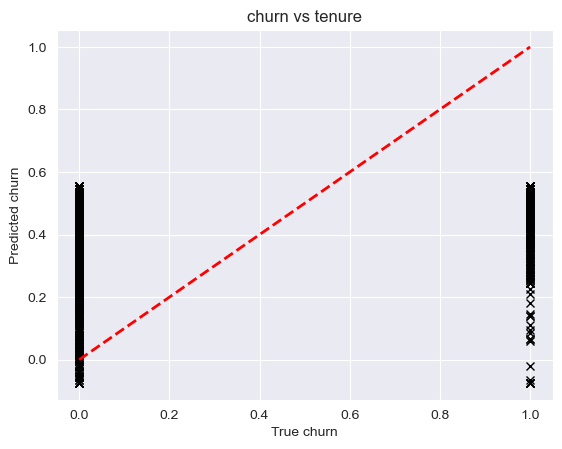

In [94]:
#plotting for tenure vs churn

#we determine the variables we want to plot as x_train and y_train 
X_train = combined_df[["tenure"]]
y_train = combined_df["churn"]

#We fit the data into the model
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)
reg_test_pred = reg.predict(X_train)

#We create the plot
plt.plot(y_train, reg_test_pred, 'kx')
plt.plot([y_train.min(), y_train.max()], 
         [y_train.min(), y_train.max()], 
         ls="--", linewidth=2, color="red")
plt.title("churn vs tenure")
plt.xlabel("True churn")
plt.ylabel("Predicted churn")
plt.show()


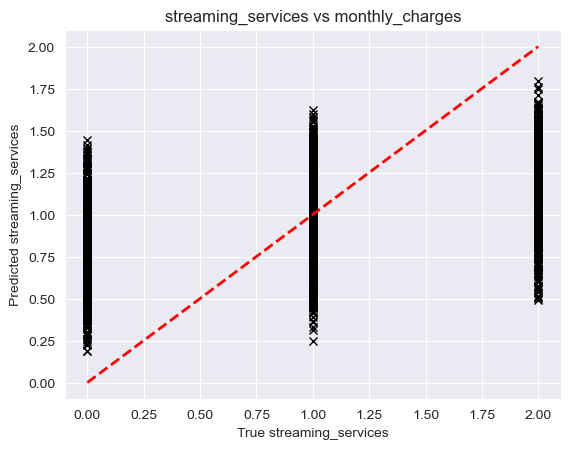

In [95]:
#plotting for monthly_charges vs churn

#we determine the variables we want to plot as x_train and y_train 
X_train = combined_df[["monthly_charges"]]
y_train = combined_df["streaming_services"]

#We fit the data into the model
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)
reg_test_pred = reg.predict(X_train)

#We create the plot
plt.plot(y_train, reg_test_pred, 'kx')
plt.plot([y_train.min(), y_train.max()], 
         [y_train.min(), y_train.max()], 
         ls="--", linewidth=2, color="red")
plt.title("streaming_services vs monthly_charges")
plt.xlabel("True streaming_services")
plt.ylabel("Predicted streaming_services")
plt.show()


**First plot (total_charges vs tenure)**
For the first plot, it is clear that the linear regression works perfectly fine, with one exception. When we hit the most expensive program, the total_charges stop growing at the same rate, which is not happening in our regression line. The relation between the data is almost perfect for linear regression, but the line should turn flatter when we hit the maximum charge point. There is some variance when it comes to the total charges at the maximum point in the data, but that is minor.

**Second plot (churn vs tenure)**
The second model is clearly not fitted for linear regression, the regression is low and that can be seen in the graph. The main reason this is happening is that even though churn is a numerical type of data, practically it is categorical having only 1 and 0 as values. So instead of linear regression, that tries to match the number continuously, we would need another algorithm that handles binary categorical data, for example logistic regression (not k-means).

**Third plot (streaming_services vs monthly_charges)**
The same problem with the second plot we identify in the third one. Streaming services are practically categorical and the regression algorithm is trying to match the categorical data 0, 1 and 2 linearly. The line is perfect visually, but the predictions are wrong because they should exist in a categorical format.


## Question 4

**a. Create a new column called tenure_category that bins tenure into three
categories: SHORT (0-12 months), MEDIUM (13-36 months), and LONG (37+
months).**


In [96]:
#We create a new variable called tenure_category and map each tenure value inside it. 
combined_df["tenure_category"] = combined_df["tenure"].map(
    lambda x: "SHORT"  if x <= 12 else
              "MEDIUM" if x <= 36 else
              "LONG"
)


**b. Prepare the data for modeling by encoding categorical variables and separating the
data into response and predictor variables. Standardise the numerical predictor
variables.**


In [97]:
#churn is what we need to find -> y
y = combined_df["churn"]
#we seperate y from x so we need to remove churn that is 
#also already an encoded categorical variable.
X = combined_df.drop(columns=["churn", "customer_id", "contract_group"])

#we encode only teh categorical the data with 0 in all categories at the first column, not to 
#get errors due to Dummy Variable Trap.
X = pd.get_dummies(X, drop_first=True)

stand_cols = ["tenure", "monthly_charges", "total_charges"]

# For standardisation, we subtract the mean from each numerical column
# and then divide by the column's standard deviation.
X[stand_cols] = (X[stand_cols] - X[stand_cols].mean()) / X[stand_cols].std()



**c. Fit a logistic regression model and interpret the fitted model. Discuss which
features have the strongest positive and negative effects on churn probability.**


In [98]:
import statsmodels.api as sm

#we need numeric inout for logit
X = X.astype(float)

#Adding the intercept
X = sm.add_constant(X)

# fitting the logistic regression model 
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.507476
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1385
Method:                           MLE   Df Model:                           14
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.2151
Time:                        03:33:16   Log-Likelihood:                -710.47
converged:                       True   LL-Null:                       -905.18
Covariance Type:            nonrobust   LLR p-value:                 2.134e-74
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -2.7469      0.541     -5.074  

**d. Perform backward elimination for your logistic regression model using a p-value
threshold of Examine the selected model and discuss your findings in relation
to the model fitted in part (c). Calculate and compare the accuracy of both models.**

In [99]:
# Predictions for the full model (threshold 0.5)
pred = logit_model.predict(X)
pred = (pred >= 0.5).astype(int)

# Accuracy for the full model
accuracy = (pred == y).mean()
print("The accuracy of the logistic model is", accuracy)


The accuracy of the logistic model is 0.725


In [100]:
a = 0.05

while True:
    model_be = sm.Logit(y, X).fit(disp=False)
    #we are ingoring the intercept, since it is not a variable to be removed
    p = model_be.pvalues.drop("const")  
    worst_p = p.max()
    
    if worst_p < a:
        #We stop when there are no insigificant variables letft to remove.
        break
    
    worst_var = p.idxmax()
    print(f"'{worst_var}' was removed with p-value = {worst_p:.4f}")
    X = X.drop(columns=[worst_var])

print("\nFinal model after backward elimination:\n")
print(model_be.summary())

'payment_method_Mailed check' was removed with p-value = 0.9883
'internet_service_Fiber optic' was removed with p-value = 0.8778
'streaming_services' was removed with p-value = 0.6152
'payment_method_Credit card' was removed with p-value = 0.5311
'monthly_charges' was removed with p-value = 0.2892
'online_security_Yes' was removed with p-value = 0.0772

Final model after backward elimination:

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1391
Method:                           MLE   Df Model:                            8
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.2124
Time:                        03:33:16   Log-Likelihood:                -712.92
converged:                       True   LL-Null:                       -905.18
Covariance Type:            nonrobust   LLR p-valu

In [101]:
# Predictions for the reduced model
be_pred_probs = model_be.predict(X)
be_pred = (be_pred_probs >= 0.5).astype(int)

# Accuracy for the reduced model
be_accuracy = (be_pred == y).mean()
print("Accuracy of reduced logistic model:", be_accuracy)

Accuracy of reduced logistic model: 0.7207142857142858


## Question 5

**a. Split the data into appropriate training and test sets (use 70% training, 30% test).**


In [102]:
#Rebuilding X and y for Question 5
#churn is what we need to find -> y
y = combined_df["churn"]
#we seperate y from x so we need to remove churn that is 
#also already an encoded categorical variable.
X = combined_df.drop(columns=["churn", "customer_id", "contract_group"])

#we encode only teh categorical the data with 0 in all categories at the first column, not to 
#get errors due to Dummy Variable Trap.
X = pd.get_dummies(X, drop_first=True)

stand_cols = ["tenure", "monthly_charges", "total_charges"]

# For standardisation, we subtract the mean from each numerical column
# and then divide by the column's standard deviation.
X[stand_cols] = (X[stand_cols] - X[stand_cols].mean()) / X[stand_cols].std()

#70% size of dataset
train_size = int(0.7 * len(y))

np.random.seed(123)

#randomising the dataset
train_select = np.random.permutation(range(len(y)))

# Creating the training and test sets for X
X_train = X.iloc[train_select[:train_size], :].reset_index(drop=True)
X_test  = X.iloc[train_select[train_size:], :].reset_index(drop=True)
# Creating the training and test sets for y
y_train = y.iloc[train_select[:train_size]].reset_index(drop=True)
y_test  = y.iloc[train_select[train_size:]].reset_index(drop=True)

**b. Fit a random forest classification model with 50 trees using the training data.
Include the argument random_state = 42 in the random forest function to ensure
reproducible results. Determine which variables are most important in predictingImportantLogistic regression to predict customer churn
p
0.05.Random forest classification to predict customer churn
customer churn. Discuss your findings in relation to the logistic regression model
from question 4.**

In [103]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

#Random forest classification with 50 trees and fixed random_state equal to 42
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=None, random_state=42)

#Fiting the model
rf_clf_fit = rf_clf.fit(X_train, y_train)

#Predicting the test set
rf_clf_test_pred = rf_clf_fit.predict(X_test)

#confusion style table
rf_clf_cross = pd.crosstab(rf_clf_test_pred, y_test)
print("Random forest crosstab:\n", rf_clf_cross)

#misclassification rate
rf_clf_misclas = (rf_clf_cross.iloc[0,1] + rf_clf_cross.iloc[1,0]) / np.sum(rf_clf_cross.values)
print("Misclassification rate:", rf_clf_misclas)

#Creating feature importance
importance = pd.Series(rf_clf.feature_importances_, index=X_train.columns)
#shoring importances
importance = importance.sort_values(ascending=False)

print("\nRandom forest feature importances:\n")
print(importance.head(10))


Random forest crosstab:
 churn    0   1
row_0         
0      218  80
1       52  71
Misclassification rate: 0.31353919239904987

Random forest feature importances:

tenure                             0.228550
total_charges                      0.227583
monthly_charges                    0.199962
streaming_services                 0.054492
tenure_category_SHORT              0.051889
contract_type_Month-to-month       0.041025
tech_support_Yes                   0.031438
payment_method_Electronic check    0.031101
online_security_Yes                0.029130
payment_method_Credit card         0.025974
dtype: float64


The most inmportant feature are tenure, total changes and monthly charges. There is no variable with a strong importnace . The remaining variables are all fo least improtance with importances less that 0.6, goit down up to 0.25 why the payment method is credit card.


**c. Use the random forest classification model to predict churn for the test set. Create
a confusion matrix and calculate the accuracy, precision, recall, and F1-score.
Interpret these metrics in the context of customer churn.**


In [104]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#Predictions
rf_pred = rf_clf_fit.predict(X_test)

#Confusion matrix
cmatrix = confusion_matrix(y_test, rf_pred)
print("Confusion matrix:\n", cmatrix)

#metrics
accuracy  = accuracy_score(y_test, rf_pred)
precesion = precision_score(y_test, rf_pred)
recall  = recall_score(y_test, rf_pred)
f1   = f1_score(y_test, rf_pred)

print("\nAccuracy :", accuracy)
print("Precision:", precesion)
print("Recall   :", recall)
print("F1-score :", f1)


Confusion matrix:
 [[218  52]
 [ 80  71]]

Accuracy : 0.6864608076009501
Precision: 0.5772357723577236
Recall   : 0.47019867549668876
F1-score : 0.5182481751824818



**d. Assess the performance of a random forest classification model with 10, 25, 50,
100, 250, 500, and 1000 trees in predicting customer churn. You should repeat the
model fit and prediction 15 times for each number of trees, using a different random
state for each repeat. Create a plot of the model performance (use F1-score) as a
function of the number of trees (use a log axis for the number of trees). The plot
should show the mean and standard error of the performance metric for each
number of trees. Discuss your findings.**


In [157]:
tries = [10, 25, 50, 100, 250, 500, 1000]

f1mean = []
f1std = []

for n in tries:
    scores = []
    #fitting the model for 15 different seeds
    for seed in range(15):
        rf_clf = RandomForestClassifier(n_estimators=n, random_state=seed)
        rf_fit = rf_clf.fit(X_train, y_train)
        pred = rf_fit.predict(X_test)
        
        #storing the F1-scores for each repeat
        scores.append(f1_score(y_test, pred))
    
    scores = np.array(scores)
    #the mean of f1-score for each repeat.
    f1mean.append(scores.mean())
    #the standard error of f1-score for each repeat.
    f1std.append(scores.std() / np.sqrt(len(scores)))


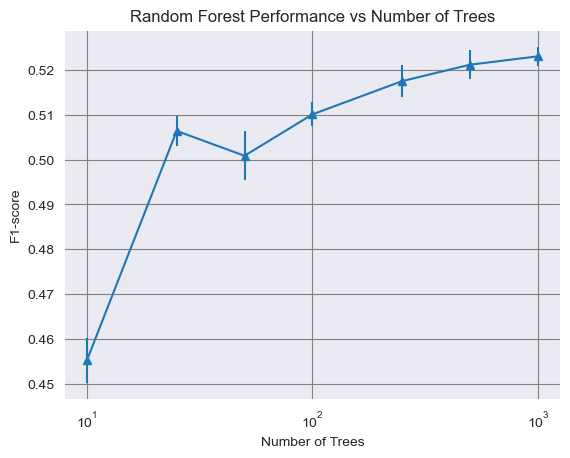

In [162]:
# Plotting the performance
plt.errorbar(tries, f1mean, yerr=f1std, fmt='^-')

# log scale for number of trees
plt.xscale("log")  
plt.xlabel("Number of Trees")
#Y will be f1-score
plt.ylabel("F1-score")
plt.title("Random Forest Performance vs Number of Trees")
#adding a grid to read easier the plot.
plt.grid(True)
plt.grid(color='gray')


plt.show()

The more the number of trees is increasing, so does the accuracy. We have a rapid increase of accuracy until the second try. Since the model at that point (f1-score at around 0.517) is also lightweight to the later models with increased number of trees that at 1000 trees we only get a maximum of approximately 0.522 f1-score. To determine further the results we would need more metrics such as accuracy.

**e. Explain why we use multiple performance metrics (accuracy, precision, recall, F1-
score) rather than just accuracy alone when evaluating a classification model for
churn prediction.**

In [ ]:
When we use multiple performance metrix, we get more informations, not only about the row performance of the model, but also about the model's stong and weak points. We we gain information on what to change in order to  improve the model.

 - Accuracy is the raw performance of teh model. We use it in order to check what percentage of precisitions is correct.
 - F1-score. Similar to accuracy, but it gives a better score when the accuracy for each variable is balanced. If it is not, it gives an a lot worse score. This way we know not only that the model works well in general, but also that there is no variable that gets confused all the time.
 - Recall is the percentage of accual possitive outcomes we found out of all the real positive outcomes. It practicaly tells us what percentage of of thereal "True" outcomes we have covered. It is useful when we are required to know if the prediction is possitive and that is our main goal. 


# Question 6

**a. Perform a k-means cluster analysis, using the numerical features ( tenure ,
monthly_charges , total_charges ). Standardise the features before clustering.
Run the clustering algorithm for different numbers of clusters (integers from 2 to
10). Plot both the inertia (within-cluster sum of squares) and silhouette score as a
function of the number of clusters. Identify the optimal number of clusters for this
data using both methods.**

C:\Users\Chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

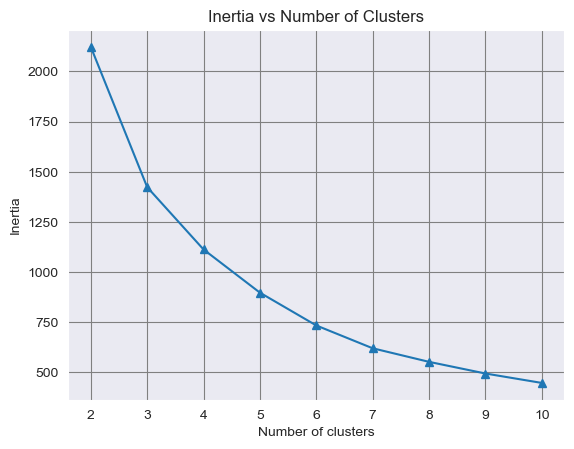

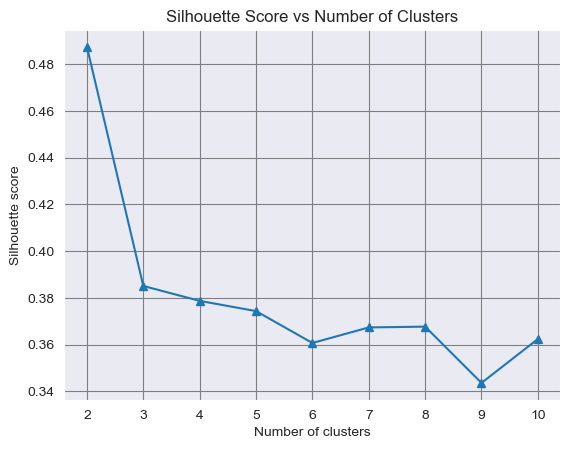

In [107]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# X has already standarised tenure, monthly_charges, total_charges
cluster = X[stand_cols]

inertia_values = []
silhouette_values = []

# we try k = 2 to 10
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(cluster)

    #inertia within cluster, sum of squares
    inertia_values.append(model.inertia_)

    #silhouette
    preds = model.predict(cluster)
    score = silhouette_score(cluster, preds)
    silhouette_values.append(score)

#Ploting inertia
plt.plot(k_values, inertia_values, marker='^')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Inertia vs Number of Clusters")
plt.grid(True)
plt.grid(color='gray')
plt.show()

# Ploting silhouette score
plt.plot(k_values, silhouette_values, marker='^')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.grid(color='gray')
plt.show()

We need the point where the decreasing rate of inertia becomes smaller while also keeping a high silhouette score.

 - Silhouette score tells us how similar the observations inside each cluster are.

 - Inertia shows how close the clusters are to their centers.

 - The inertia curve stops rapidly decreasing at k = 4.

 - The silhouette score has its highest point at k = 2, and then it drops by around 25%.

K-means is based on grouping data points that are similar to each other. Because of that, the silhouette score describes the goal of K-means clustering better (compact and well-separated clusters).

The huge drop in silhouette score after k = 2 justifies choosing k = 2 as the best clustering choice.


**b. Perform a k-means cluster analysis using the optimal number of clusters (identified
in part (a)), and identify the most discriminatory variables. Create box plots for each
numerical variable, with the data separated by cluster. Calculate the mean values
for each variable within each cluster.**


C:\Users\Chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\Chara\AppData\Local\Temp\ipykernel_42640\943513248.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster["kpreds"] = preds


          tenure  monthly_charges  total_charges
kpreds                                          
0      -0.511010        -0.111291      -0.512539
1       1.412145         0.307547       1.416372


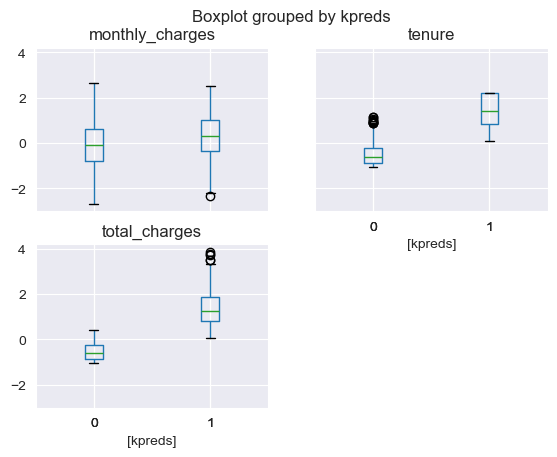

In [108]:

#creating the model model
model.fit(cluster)
preds = model.predict(cluster)

#adding the predictios into the cluster variable in order to preserve the data later.
cluster["kpreds"] = preds
print(cluster.groupby("kpreds").mean())

#the box plots
cluster.boxplot(by="kpreds")
plt.show()


**c. Create a series of scatter plots for pairs of the most discriminatory variables,colouring the points by cluster number. Also create a scatter plot showing clustersin the space of tenure vs monthly_charges, and overlay the churn status usingdifferent markers. Discuss your findings about the relationship between clustersand churn.**


From the box plots of question 6.b., we can easily conclude that the most discriminatory variables are tenure and total_charges, while monthly charges is not discriminatory at all.

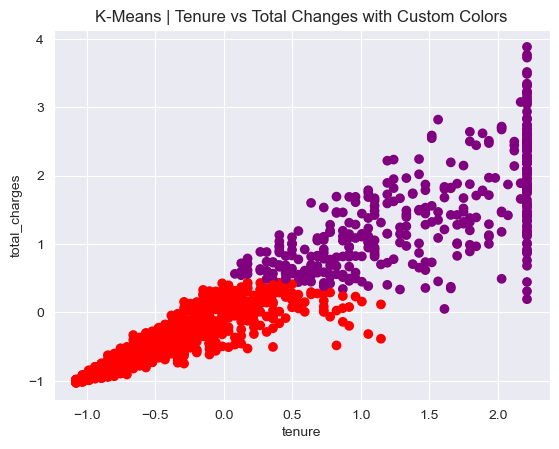

In [147]:
# Custom colors for each cluster
colors = ["red", "purple"]   #Red and Purple

# Create the scatter plot with red for 0 purple for 1.
plt.scatter(cluster['tenure'], 
            cluster['total_charges'], 
            c=[colors[label] for label in preds])

plt.xlabel('tenure')
plt.ylabel('total_charges')
plt.title('K-Means | Tenure vs Total Changes with Custom Colors')
plt.show()

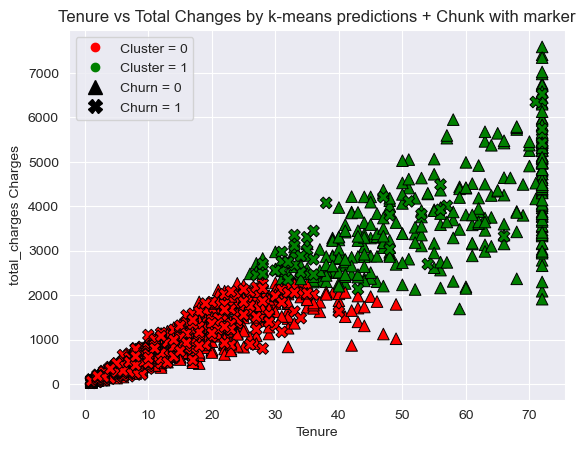

In [156]:
import matplotlib.pyplot as plt
import numpy as np

# colors for the clusters
colors = ["red", "green"]

# Markers in order to present chum
markers = {0: "^", 1: "X"}

plt.figure()

#One time when the churn is 0 for the ^ shapes and one time when churn is 1 for the X shapes
for i in [0, 1]:
    #the data for churm = 0 and churn = 1.
    subset = combined_df[combined_df["churn"] == i]

    plt.scatter(
        subset["tenure"], 
        subset["total_charges"],
        c=[colors[label] for label in preds[subset.index]],
        marker=markers[i],
        s=70,
        edgecolor="black",
        linewidth=0.7
    )
#Labels
plt.xlabel("Tenure")
plt.ylabel("total_charges Charges")
plt.title("Tenure vs Total Changes by k-means predictions + Churn with marker")

#Legend for colors
colour_handles = [
    plt.Line2D([], [], marker='o', color=color, linestyle='',
               label=f"Cluster = {i}")
    for i, color in enumerate(colors)
]

# Legend for churn markers
churn_handles = [
    plt.Line2D([], [], marker=markers[i], color="black", linestyle='',
               markersize=10, label=f"Churn = {i}")
    for i in [0, 1]
]

plt.legend(handles=colour_handles + churn_handles)
plt.show()


The plot shows us that there is a strong correlation between the churn and tenure-total_changes. Also, we have seen that optimising the output we got from k-mean, has the potential toThe plot shows us that there is a strong correlation between churn and the tenure–total_charges relationship. Also, we have seen that optimising the output we got from k-means has the potential to produce a lightweight model with reasonable predictive power. Generally, the plot looks like a fair first effort at creating a model that predicts churn. Everything has been separated in a very nice way, with some failed “predictions” in the centre — a small error that can be easily optimised if we actually try to create a model — and a few cases that could be noise, where one or two wrong predictions are placed around numerous correct ones. From that plot we learned a strong correlation pattern and the possibility of building a simple and lightweight model that helps explain churn behaviour. produce a lightweight model with reasonable predictive power. Generally, the plot looks like fair first effort of creating a model that predicts churn. Everything has beed apportioned in a very nice way, with some failed "predictions" in the center, a small error that can be easily optimised if we accualy try to create a model and a few cases that could be noise that one or two wrong predictions are placed areound noumerous correct ones. From that plot we learned a strong correlation combination and the possibility of using this structure as a basis for a simple model that helps explain churn behaviour. 

**d. Identify another clustering algorithm that may be suitable for this data. Give an
overview of your chosen algorithm and discuss the type of problems it works best
for. Repeat parts (a)-(c) using your chosen algorithm. Discuss your results in**

DBSCAN can be a better alternative than k-means.

- k-means is a center-based algorithm, so the clusters need to be more like circles for it to work correctly.

- DBSCAN, on the other hand, is based on how close the data points are to each other and forms clusters from dense areas.

Our plot is more like a consecutive spread of data rather than separate circles, so DBSCAN would probably perform noticeably better just by changing the algorithm.

eps values:  [0.3, 0.5, 0.7, 0.9, 1.1]
Number of clusters (excluding noise):  [4, 1, 1, 1, 1]
Silhouette Score:  [np.float64(0.12948399993616258), nan, nan, nan, nan]


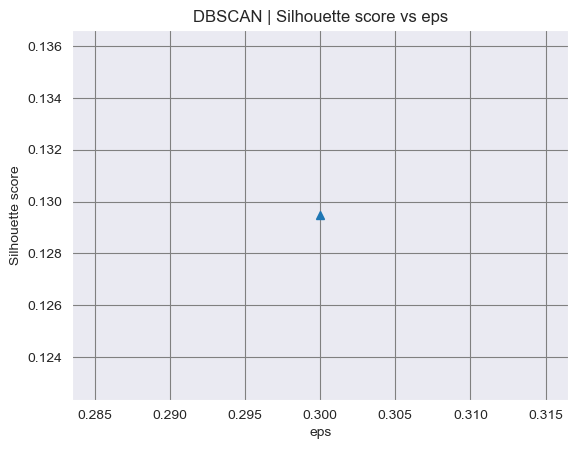

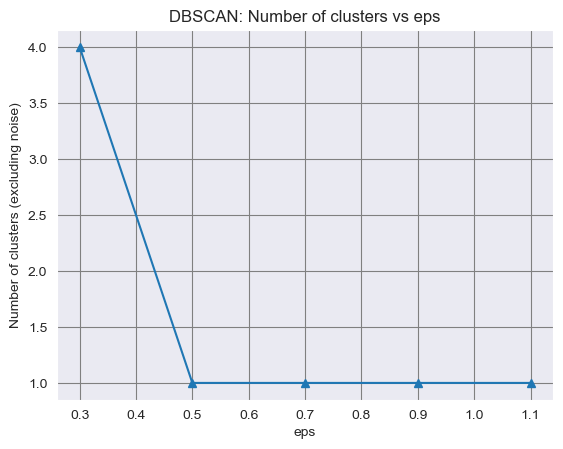

In [169]:
#Based on question 6.a.
from sklearn.cluster import DBSCAN


# X has already standardised tenure, monthly_charges, total_charges
cluster = X[stand_cols]

eps_val = [0.3, 0.5, 0.7, 0.9, 1.1]
silhouette_val = []
clusters_list = []

for eps in eps_val:
    #Creating the DBSCAN model for this eps.
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(cluster)

    #number of clusters, excluding noise (-1).
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    clusters_list.append(clusters)

    # silhouette is only defined if we have at least 2 clusters, 
    #like before that we started with k=2.
    if clusters > 1:
        score = silhouette_score(cluster, labels)
    else:
        score = np.nan
    silhouette_val.append(score)

print("eps values: ", eps_val)
print("Number of clusters (excluding noise): ", clusters_list)
print("Silhouette Score: ", silhouette_val)

# plot silhouette vs eps
plt.plot(eps_val, silhouette_val, marker="^")
plt.xlabel("eps")
plt.ylabel("Silhouette score")
plt.title("DBSCAN | Silhouette score vs eps")
plt.grid(True)
plt.grid(color='gray')
plt.show()

# plot number of clusters vs eps
plt.plot(eps_val, clusters_list, marker="^")
plt.xlabel("eps")
plt.ylabel("Number of clusters (excluding noise)")
plt.title("DBSCAN: Number of clusters vs eps")
plt.grid(True)
plt.grid(color='gray')
plt.show()
